In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_124.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_949.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_786.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_371.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_599.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_802.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_955.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/Tr-pi_778.jpg
/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training/pituitary/

In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import vit_b_16, ViT_B_16_Weights
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [5]:
from torchvision import datasets
from torch.utils.data import ConcatDataset

train_dir = "/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Training"
test_dir  = "/kaggle/input/datasets/ogprakhar/brain-tumor-detection-2-0/Testing"
train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
test_data  = datasets.ImageFolder(test_dir, transform=train_transforms)

# Combine both datasets
full_dataset = ConcatDataset([train_data, test_data])

CLASS_NAMES = train_data.classes

print("Classes:", CLASS_NAMES)
print("Total images:", len(full_dataset))

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Total images: 7200


In [6]:
from torch.utils.data import random_split

dataset_size = len(full_dataset)

train_size = int(0.7 * dataset_size)
test_size  = dataset_size - train_size

train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size]
)

print("Training Images:", train_size)
print("Testing Images:", test_size)

Training Images: 5040
Testing Images: 2160


In [7]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print("DataLoaders Ready")

DataLoaders Ready


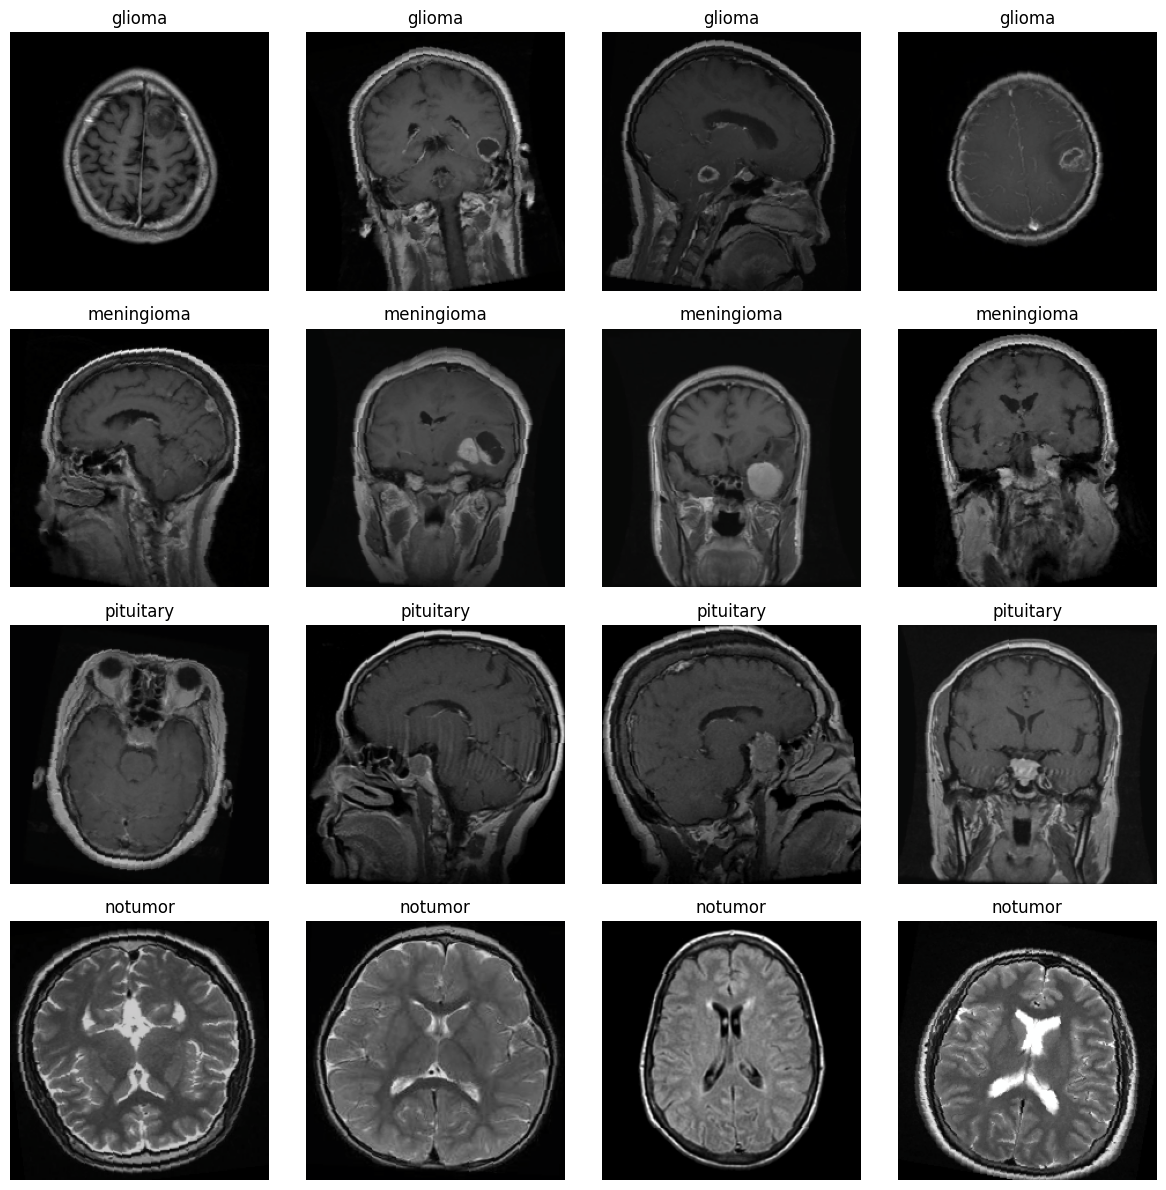

MRI visualization saved!


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Desired class order
display_order = ['glioma', 'meningioma', 'pituitary', 'notumor']

class_images = {cls: [] for cls in display_order}

for images, labels in train_loader:

    for img, label in zip(images, labels):

        class_name = CLASS_NAMES[label]

        if class_name in class_images and len(class_images[class_name]) < 4:
            class_images[class_name].append(img)

    if all(len(v) == 4 for v in class_images.values()):
        break


plt.figure(figsize=(12,12))

index = 1

for cls in display_order:

    for img in class_images[cls]:

        plt.subplot(4,4,index)

        img = img.permute(1,2,0).cpu().numpy()

        # undo normalization
        mean = np.array([0.485,0.456,0.406])
        std  = np.array([0.229,0.224,0.225])

        img = std * img + mean
        img = np.clip(img,0,1)

        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

        index += 1


plt.tight_layout()

plt.savefig("/kaggle/working/mri_samples_per_class.png", dpi=300)

plt.show()

print("MRI visualization saved!")

In [9]:
# Number of classes
NUM_CLASSES = len(CLASS_NAMES)

print("Number of Classes:", NUM_CLASSES)

# Load pretrained Vision Transformer
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights=weights)

# Modify classifier head
model.heads.head = nn.Linear(
    model.heads.head.in_features,
    NUM_CLASSES
)

model = model.to(device)

print("ViT Model Loaded")

Number of Classes: 4
ViT Model Loaded


In [10]:
import torch.optim as optim
import torch.nn as nn

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=120
)

print("Optimizer, Loss, Scheduler initialized")





Optimizer, Loss, Scheduler initialized


In [11]:
EPOCHS = 120

history = {
    "train_acc": [],
    "test_acc": [],
    "train_loss": []
}

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120)

In [13]:
import os
import torch

checkpoint_path = "/kaggle/working/checkpoint.pth"
best_model_path = "/kaggle/working/best_vit_brain_tumor.pth"

start_epoch = 0
best_acc = 0.0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)

    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    #  Safe scheduler loading
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        print(" Scheduler loaded")
    else:
        print(" Scheduler not found, using fresh scheduler")

    start_epoch = checkpoint['epoch'] + 1
    print(f" Resuming from epoch {start_epoch}")
else:
    print(" Starting fresh training")
 

 Scheduler loaded
 Resuming from epoch 120


In [14]:
import os
print(os.listdir())

['accuracy_graph.png', 'history.pkl', 'best_vit_brain_tumor.pth', 'checkpoint.pth', 'confusion_matrix.png', '.virtual_documents', 'mri_samples_per_class.png']


In [15]:
import os
import pickle

# HISTORY LOAD / INIT (VERY IMPORTANT)
history_path = "/kaggle/working/history.pkl"

if os.path.exists(history_path):
    with open(history_path, "rb") as f:
        history = pickle.load(f)
    print(" History loaded")
else:
    history = {
        "train_acc": [],
        "test_acc": [],
        "train_loss": []
    }
    print(" New history created")

 History loaded


In [24]:
for epoch in range(start_epoch, EPOCHS):

    # -------- TRAINING --------
    model.train()
    correct = 0
    total = 0
    train_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = 100 * correct / total
    train_loss = train_loss / len(train_loader)   # ✅ FIX (average loss)

    # -------- TESTING --------
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_acc = 100 * correct / total

    # -------- STORE HISTORY (CRITICAL) --------
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)
    history["train_loss"].append(train_loss)

    # -------- SAVE HISTORY --------
    with open(history_path, "wb") as f:
        pickle.dump(history, f)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Acc: {train_acc:.2f}% | "
          f"Test Acc: {test_acc:.2f}%")

    # -------- SAVE BEST MODEL --------
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), best_model_path)
        print(" Best model saved!")

    # -------- SAVE CHECKPOINT --------
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
    }, checkpoint_path)

In [17]:
print(len(history["train_acc"]))
print(len(history["test_acc"]))

120
120


In [18]:
print(len(history["train_acc"]))

120


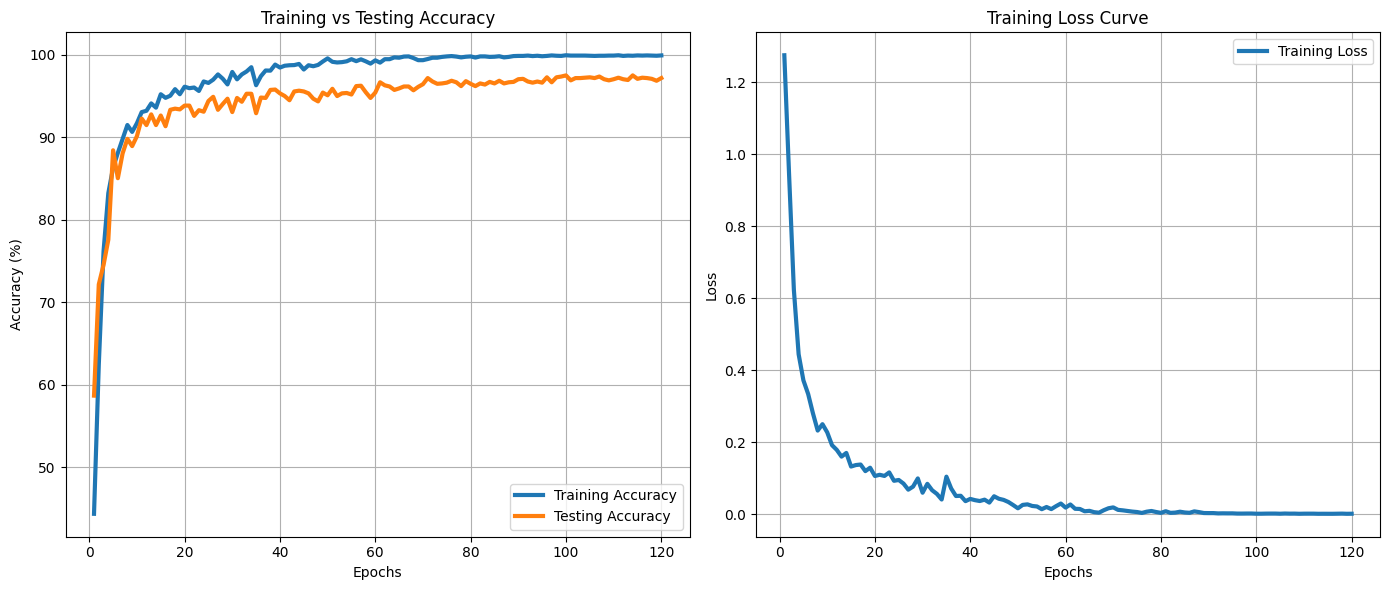

Accuracy graph saved!


In [19]:
epochs_range = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)

plt.plot(epochs_range, history["train_acc"], label="Training Accuracy", linewidth=3)
plt.plot(epochs_range, history["test_acc"], label="Testing Accuracy", linewidth=3)

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Testing Accuracy")

plt.legend()
plt.grid()

plt.subplot(1,2,2)

plt.plot(epochs_range, history["train_loss"], label="Training Loss", linewidth=3)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig("/kaggle/working/accuracy_graph.png", dpi=300)

plt.show()
print("Accuracy graph saved!")

In [20]:
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

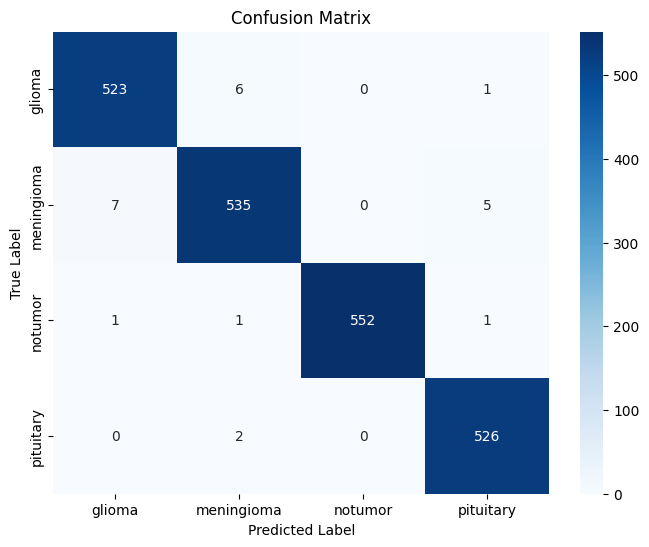

Confusion matrix saved!


In [21]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig("/kaggle/working/confusion_matrix.png", dpi=300)

plt.show()

print("Confusion matrix saved!")

In [22]:
import numpy as np

sensitivity = []
specificity = []

for i in range(len(cm)):
    
    TP = cm[i,i]
    FN = cm[i,:].sum() - TP
    FP = cm[:,i].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    sens = TP / (TP + FN)
    spec = TN / (TN + FP)

    sensitivity.append(sens)
    specificity.append(spec)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

print("Average Sensitivity:", np.mean(sensitivity))
print("Average Specificity:", np.mean(specificity))

Sensitivity: [np.float64(0.9867924528301887), np.float64(0.9780621572212066), np.float64(0.9945945945945946), np.float64(0.9962121212121212)]
Specificity: [np.float64(0.9950920245398773), np.float64(0.9944203347799132), np.float64(1.0), np.float64(0.9957107843137255)]
Average Sensitivity: 0.9889153314645278
Average Specificity: 0.9963057859083789


In [23]:
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(all_labels, all_preds) * 100

print("Accuracy:", accuracy)

print(classification_report(
    all_labels,
    all_preds,
    target_names=CLASS_NAMES
))

Accuracy: 98.88888888888889
              precision    recall  f1-score   support

      glioma       0.98      0.99      0.99       530
  meningioma       0.98      0.98      0.98       547
     notumor       1.00      0.99      1.00       555
   pituitary       0.99      1.00      0.99       528

    accuracy                           0.99      2160
   macro avg       0.99      0.99      0.99      2160
weighted avg       0.99      0.99      0.99      2160

